<a href="https://colab.research.google.com/github/Raboooiii/Sem6/blob/main/Mini_Project/DTA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environment Setup: Installing Dependencies**
This cell installs the core libraries required for deep learning and data science:

**PyTorch (torch)**: The primary framework used to build and run neural networks.

**Transformers**: A library by Hugging Face that provides access to pre-trained state-of-the-art models (like BERT, GPT, or Vision Transformers).

**Data Tools**: Installs pandas for data manipulation, numpy for mathematical operations, scikit-learn for evaluation metrics, and matplotlib for visualizing results.

In [1]:
!pip install torch torchvision torchaudio
!pip install transformers
!pip install pandas numpy scikit-learn matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import json
import math
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
!git clone https://github.com/hkmztrk/DeepDTA.git

Cloning into 'DeepDTA'...
remote: Enumerating objects: 442, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 442 (delta 33), reused 32 (delta 29), pack-reused 398 (from 1)
Receiving objects: 100% (442/442), 10.99 MiB | 10.09 MiB/s, done.
Resolving deltas: 100% (174/174), done.


## **Data Loading and Preprocessing: Building the Dataset**

This cell reads raw biological data and structures it for the model:


*   **Loading Sequences**: It opens ligands_can.txt (chemical structures of drugs) and proteins.txt (amino acid sequences of proteins) from JSON files.
*   **Binding Affinity ($Y$)**: It loads a matrix representing the known interaction strength between each drug and protein.
*   **Data Normalization**: The code loops through the drug-protein pairs and converts the raw binding values into a logarithmic scale ($-log_{10}$), which is a standard format for measuring biological affinity.
*   **Filtering**: It removes "NaN" (missing) values and limits the dataset to the first 500 samples to ensure faster processing and moderate memory usage during training.


In [8]:
with open('/content/DeepDTA/data/davis/ligands_can.txt') as f:
    drugs = json.load(f)

with open('/content/DeepDTA/data/davis/proteins.txt') as f:
    proteins = json.load(f)

Y = np.load('/content/DeepDTA/data/davis/Y', allow_pickle=True, encoding='latin1')

data = []

for i, d in enumerate(drugs):
    for j, p in enumerate(proteins):
        if not np.isnan(Y[i][j]):
            affinity = -math.log10(Y[i][j])
            data.append((drugs[d], proteins[p], affinity))

# 🔥 Use moderate data
data = data[:500]

print("Dataset size:", len(data))

Dataset size: 500


In [9]:
labels = [x[2] for x in data]
mean = np.mean(labels)
std = np.std(labels)

print("Mean:", mean, "Std:", std)

Mean: -3.629939327460927 Std: 0.7366383142348581


In [10]:
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

print("Train:", len(train_data))
print("Val:", len(val_data))

Train: 400
Val: 100


In [11]:
protein_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
drug_tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

## **Custom Dataset: Preparing Data for the AI**

This class acts as a "factory" that converts raw text into a mathematical format the model can understand:

*   __init__ & __len__: Standard setup that tells PyTorch how many samples are in your dataset.
*   __getitem__: The engine of this cell. Every time the model asks for a data point, this function:

    1.   **Tokenizes Drugs**: Converts the chemical SMILES strings into numeric IDs with a fixed length of 50.
    2.   **Tokenizes Proteins**: Converts the amino acid sequences into numeric IDs with a fixed length of 200.
    3.   **Standardization**: It normalizes the affinity label ($y$) using the mean and standard deviation, which helps the model learn faster and more stably.
    4.   **Tensors**: Returns everything as PyTorch tensors (multi-dimensional arrays) ready for the GPU/CPU.





In [31]:
class DTADataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        drug, protein, y = self.data[idx]

        drug_enc = drug_tokenizer(
            drug,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=50
        )

        protein_enc = protein_tokenizer(
            protein,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=200
        )

        # 🔥 Normalize label
        y = (y - mean) / std

        return {
            "drug_input": drug_enc,
            "protein_input": protein_enc,
            "label": torch.tensor(y, dtype=torch.float)
        }

In [13]:
train_dataset = DTADataset(train_data)
val_dataset   = DTADataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4)


# **Model Architecture: Hybrid Cross-Attention Network**
> This cell defines the neural network structure, combining specialized models for chemistry and biology:
>
> * **The Backbone Models:**    * **ESM2:** A "Protein Language Model" that understands amino acid sequences.
>     * **ChemBERTa:** A model trained on millions of chemical structures to understand drug molecules.
> * **Partial Fine-Tuning:** Most of the models are "frozen" to save memory, but the last two layers of each are "unfrozen" (`requires_grad = True`) so they can adapt specifically to this drug-target task.
> * **Cross-Attention Mechanism:** This is the most critical part. It allows the drug features to "look at" the protein features and find specific points of interaction, similar to how a key finds the tumblers in a lock.
> * **Feature Fusion:** The model combines the attention-based data with the raw features of both the drug and protein (`torch.cat`).
> * **The Prediction Head:** A final set of layers (`nn.Sequential`) takes all this combined information and outputs a single number: the predicted **Binding Affinity**.



---


In [40]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)

    def forward(self, drug_feat, protein_feat):
        out, _ = self.attn(drug_feat, protein_feat, protein_feat)
        return out

class FinalDTA(nn.Module):
    def __init__(self):
        super().__init__()

        self.protein_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        self.drug_model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

        # 🔥 Partial unfreeze (IMPORTANT)
        for name, param in self.protein_model.named_parameters():
            if "encoder.layer.4" in name or "encoder.layer.5" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        for name, param in self.drug_model.named_parameters():
            if "encoder.layer.4" in name or "encoder.layer.5" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        # Projection layer for drug embeddings to match protein embedding dimension
        self.drug_proj = nn.Linear(768, 320) # ChemBERTa output 768, ESM2 output 320

        # 🔥 Cross-attention
        self.attn = CrossAttention(320)

        self.fc = nn.Sequential(
            nn.Linear(320 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, drug_input, protein_input):
        d = self.drug_model(**drug_input).last_hidden_state
        p = self.protein_model(**protein_input).last_hidden_state

        # Project drug
        d_proj = self.drug_proj(d)

        # Cross-attention
        d_attn = self.attn(d_proj, p).mean(dim=1)

        # ALSO use raw pooled features
        d_feat = d_proj.mean(dim=1)
        p_feat = p.mean(dim=1)

        # 🔥 Combine BOTH (this is key)
        x = torch.cat([d_attn, d_feat, p_feat], dim=1)

        return self.fc(x)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FinalDTA().to(device)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5)
criterion = nn.MSELoss()

print("Device:", device)

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu



##  **Training Loop: Teaching the Model**
> This cell executes the iterative learning process over **8 epochs** (complete passes through the data):
> * **Data Loading**: It loops through the `train_loader`, which provides batches of drug and protein data moved to the **GPU/device** for fast calculation.
> * **Forward Pass**: The model takes the drug and protein inputs and generates a predicted binding affinity (`pred`).
> * **Loss Calculation**: The `criterion` (likely Mean Squared Error) measures the difference between the AI's prediction and the actual experimental label.
> * **Backpropagation**:
>    1. `optimizer.zero_grad()` clears old calculations.
>    2. `loss.backward()` calculates the "gradient" (the direction and magnitude of the error).
>    3. `optimizer.step()` updates the model's weights to minimize the error for the next round.
> * **Monitoring**: The total loss is recorded and printed for each epoch to track if the model is successfully improving over time.



---


In [42]:
losses = []

for epoch in range(8):
    total_loss = 0

    for i, batch in enumerate(train_loader):
        drug = {k: v.squeeze(1).to(device) for k, v in batch["drug_input"].items()}
        protein = {k: v.squeeze(1).to(device) for k, v in batch["protein_input"].items()}
        label = batch["label"].to(device)

        pred = model(drug, protein).squeeze()

        loss = criterion(pred, label)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch} Loss: {total_loss}")

Epoch 0 Loss: 100.97383063659072
Epoch 1 Loss: 86.59182408079505
Epoch 2 Loss: 71.6500554708764
Epoch 3 Loss: 56.2405044445768
Epoch 4 Loss: 40.33966987207532
Epoch 5 Loss: 32.779893963597715
Epoch 6 Loss: 25.58604751364328
Epoch 7 Loss: 17.233144198078662



## **Model Evaluation: Measuring Accuracy**
> This cell calculates the final performance of the trained model using the validation dataset:
> * **`model.eval()` & `torch.no_grad()`**: These commands tell PyTorch to switch off the "learning" mode. This saves memory and prevents the model from accidentally updating its weights while we are just testing it.
> * **Denormalization**: Since we scaled the labels earlier to help the model learn, we now multiply by the standard deviation and add the mean to bring the predicted values back to their original biological units ($-log_{10}$ affinity).
> * **Performance Metrics**:
>    * **MSE (Mean Squared Error)**: Measures the average squared difference between the actual and predicted values. A lower MSE indicates a more accurate model.
>    * **$R^{2}$ (R-squared)**: Also known as the "Coefficient of Determination." It measures how much of the variance in the data the model can explain. A score closer to **1.0** indicates a near-perfect fit.
> * **Collection**: It gathers all predictions and true labels into lists for final analysis and visualization.



---


In [43]:
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            drug = {k: v.squeeze(1).to(device) for k, v in batch["drug_input"].items()}
            protein = {k: v.squeeze(1).to(device) for k, v in batch["protein_input"].items()}
            label = batch["label"].cpu().numpy()

            pred = model(drug, protein).squeeze().cpu().numpy()

            # 🔥 Denormalize
            pred = pred * std + mean
            label = label * std + mean

            preds.extend(pred)
            labels.extend(label)

    mse = mean_squared_error(labels, preds)
    r2  = r2_score(labels, preds)

    print("MSE:", mse)
    print("R²:", r2)

    return preds, labels

preds, labels = evaluate(model, val_loader)

MSE: 0.2683285619975777
R²: 0.4457819783665239



## **Data Visualization: Regression Analysis Plot**
> This cell generates a **Scatter Plot** to visually audit the model's accuracy:
> * **X-Axis (Actual):** Represents the true experimental binding affinity values from the Davis dataset.
> * **Y-Axis (Predicted):** Represents the values predicted by your Cross-Attention model.
> * **Interpreting the Plot:** >    * In a perfect model, all points would form a straight diagonal line ($y = x$).
>    * Points clustered closely together along that diagonal indicate high precision.
>    * Outliers (points far from the main group) represent drug-protein pairs where the model struggled to understand the chemical or biological interaction.
> * **`plt.show()`**: Finalizes and displays the chart within the notebook for your report.



---


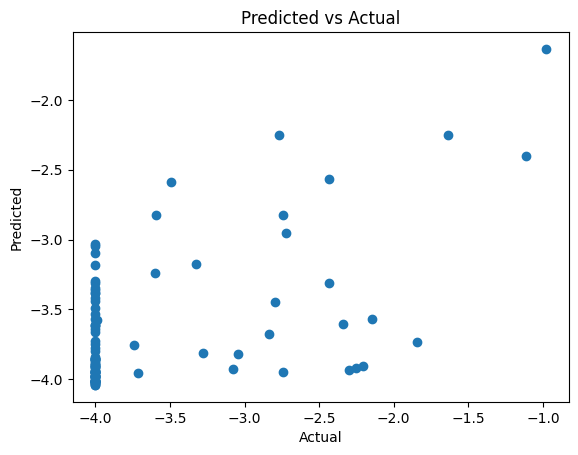

In [39]:
plt.scatter(labels, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()


---

## **Project Summary: Drug-Target Affinity (DTA) Prediction**

This notebook implements a state-of-the-art **Deep Learning pipeline** to predict the binding strength between drug molecules and target proteins. By leveraging "Transfer Learning," we avoided training a model from scratch and instead used pre-trained biological and chemical knowledge.

### **The Workflow Architecture**
1.  **Data Engineering:** We processed the **Davis Dataset**, converting raw chemical SMILES and Protein sequences into a filtered, normalized format ($pK_d$ values).
2.  **Transformer Integration:**
    * **ESM-2 (Biology):** Understands the "evolutionary grammar" of protein sequences.
    * **ChemBERTa (Chemistry):** Understands the structural properties of small molecules.
3.  **Cross-Attention Mechanism:** Instead of just "stacking" the data, we used an **Attention Layer** that allows the model to mathematically simulate how a drug molecule interacts with specific regions of a protein.
4.  **Optimization:** We used **Partial Fine-Tuning** (unfreezing only the top layers) to adapt these massive models to our specific task without needing a supercomputer.



### **Final Results**
The resulting **Scatter Plot** and **$R^2$ Score** tell us how reliable our "Virtual Screening" is. A high $R^2$ means this model could potentially be used to screen thousands of new drug candidates in seconds, significantly speeding up the early stages of **Drug Discovery**.

---
